### __Import__

In [1]:
import json
from data_model_loader import load_model, load_coco_2014_dataset, get_image_ids

model = load_model()
images = load_coco_2014_dataset()

# load file paths
with open('config.json', 'r') as file:
    config = json.load(file)
coco_folder = config['coco_folder']
annotation_file_path = config['annotation_file_path']

filename_to_image_id = get_image_ids()

OD model already present locally.
data/coco2014\val2014.zip already exists. Skipping download.
data/coco2014\val2014 already exists. Skipping extraction.
data/coco2014\annotations_trainval2014.zip already exists. Skipping download.
data/coco2014\annotations_trainval2014 already exists. Skipping extraction.
COCO 2014 dataset download and extraction complete.
Randomly selecting 1500 pictures ..
Done!


BS

In [2]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json

with open('config.json', 'r') as file:
    config = json.load(file)


RESULTS_DIR = config["results_dir"]
ANNOTATION_FILE_PATH = config['annotation_file_path']
annType = 'bbox'
results_file_path =  RESULTS_DIR +"ssd_mobilenet_results.json"
#initialize COCO ground truth api
cocoGt=COCO(ANNOTATION_FILE_PATH)

#initialize COCO detections api
cocoDt=cocoGt.loadRes(results_file_path)

# prepare ids
imgIds=sorted(cocoGt.getImgIds())
#imgIds=imgIds[0:100]
#imgId = imgIds[np.random.randint(100)]

# evaluate
cocoEval = COCOeval(cocoGt, cocoDt, annType)
cocoEval.params.imgIds = imgIds
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()

loading annotations into memory...
Done (t=3.69s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.79s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=40.23s).
Accumulating evaluation results...
DONE (t=6.97s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.020
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.014
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.022
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.013
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

Correct

In [29]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json

with open('config.json', 'r') as file:
    config = json.load(file)

with open(results_file_path, 'r') as file:
    results = json.load(file)

RESULTS_DIR = config["results_dir"]
ANNOTATION_FILE_PATH = config['annotation_file_path']
annType = 'bbox'
results_file_path =  RESULTS_DIR +"ssd_mobilenet_int8_results.json"
#initialize COCO ground truth api
cocoGt=COCO(ANNOTATION_FILE_PATH)

#initialize COCO detections api
cocoDt=cocoGt.loadRes(results_file_path)

# only ids that were used for prediction
image_ids = [r["image_id"] for r in results]

# evaluate
cocoEval = COCOeval(cocoGt, cocoDt, annType)
cocoEval.params.imgIds = image_ids
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()

loading annotations into memory...
Done (t=3.93s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.56s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=6.28s).
Accumulating evaluation results...
DONE (t=1.80s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.082
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.140
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.083
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.017
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.078
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.166
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.111
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.175
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [2]:
from evaluate import evaluate_predictions
import json
with open('config.json', 'r') as file:
    config = json.load(file)


RESULTS_DIR = config["results_dir"]
m = evaluate_predictions(RESULTS_DIR,"ssd_mobilenet_float32" )

loading annotations into memory...
Done (t=4.09s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.85s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.42s).
Accumulating evaluation results...
DONE (t=1.95s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.249
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.419
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.250
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.042
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.224
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.512
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.247
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.363
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [3]:
m

{'AP_IoU_0.50:0.95_all_maxDets_100': 0.24936269251937035,
 'AP_IoU_0.50_all_maxDets_100': 0.4191796085479147,
 'AP_IoU_0.75_all_maxDets_100': 0.25046049370914114,
 'AP_IoU_0.50:0.95_small_maxDets_100': 0.04170488309399984,
 'AP_IoU_0.50:0.95_medium_maxDets_100': 0.2235949047786725,
 'AP_IoU_0.50:0.95_large_maxDets_100': 0.5118105107474481,
 'AR_IoU_0.50:0.95_all_maxDets_1': 0.24653317544149933,
 'AR_IoU_0.50:0.95_all_maxDets_10': 0.36302163003333926,
 'AR_IoU_0.50:0.95_all_maxDets_100': 0.38324030300502215,
 'AR_IoU_0.50:0.95_small_maxDets_100': 0.09452934686018061,
 'AR_IoU_0.50:0.95_medium_maxDets_100': 0.3980659312703328,
 'AR_IoU_0.50:0.95_large_maxDets_100': 0.7141738530968645}

# Plots

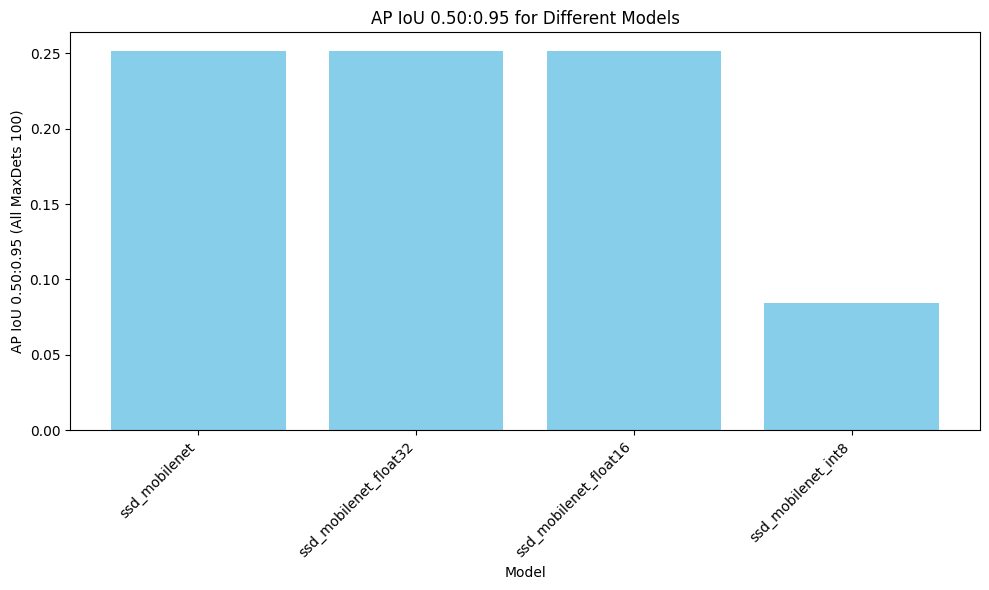

In [2]:
import json
import matplotlib.pyplot as plt

# Load the JSON data from a file
with open('output/output.json', 'r') as f:
    data = json.load(f)

# Initialize lists for models and corresponding AP_IoU_0.50:0.95_all_maxDets_100 values
models = []
ap_values = []

# Extract model names and corresponding metric value for AP_IoU_0.50:0.95_all_maxDets_100
for model_name, model_data in data.items():
    models.append(model_name)
    ap_values.append(model_data['metrics']['AP_IoU_0.50:0.95_all_maxDets_100'])

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, ap_values, color='skyblue')

# Labeling the chart
plt.xlabel('Model')
plt.ylabel('AP IoU 0.50:0.95 (All MaxDets 100)')
plt.title('AP IoU 0.50:0.95 for Different Models')
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
# Load the JSON data from a file
with open('output/output.json', 'r') as f:
    data = json.load(f)

model_names = []
footprint = []
runtime = []

for model, model_data in data.items():
    model_names.append(model)
    footprint.append(model_data["memory_footprint"])
    runtime.append(model_data["avg_inference_time"])



df = pd.DataFrame({
    'Model': model_names,
    'Memory Footprint': footprint,
    'Mean Inference Time': runtime
})
df.to_latex(index=False, caption='Model Comparison', label='tab:model_metrics')

'\\begin{table}\n\\caption{Model Comparison}\n\\label{tab:model_metrics}\n\\begin{tabular}{lrr}\n\\toprule\nModel & Memory Footprint & Mean Inference Time \\\\\n\\midrule\nssd_mobilenet & 75.120824 & 0.021882 \\\\\nssd_mobilenet_float32 & 23.720039 & 0.115962 \\\\\nssd_mobilenet_float16 & 12.166817 & 0.117698 \\\\\nssd_mobilenet_int8 & 6.706703 & 0.167178 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

Average Precision

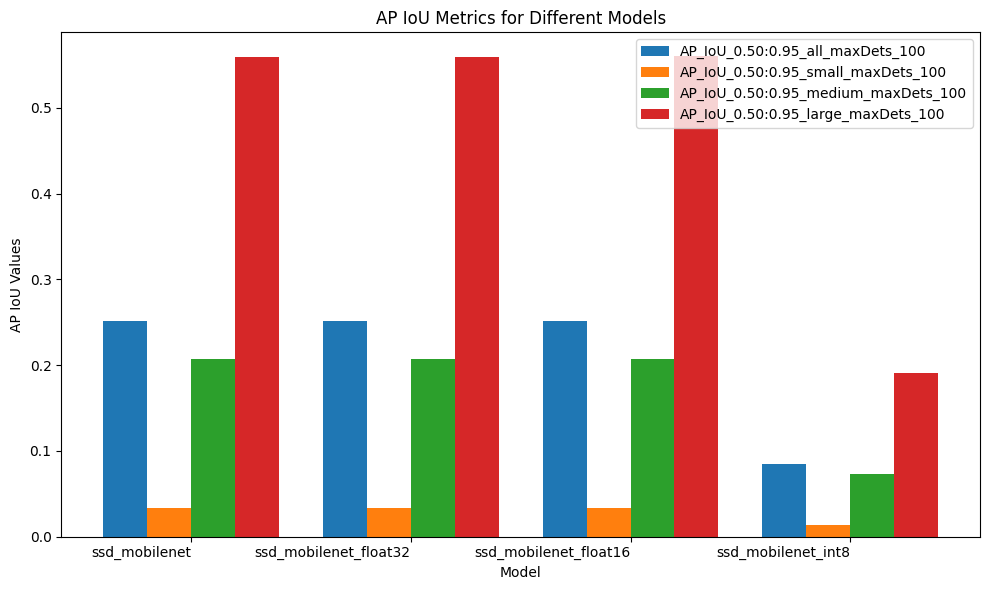

In [ ]:
import numpy as np
# Define the metric names to extract
metrics = [
    "AP_IoU_0.50:0.95_all_maxDets_100",
    "AP_IoU_0.50:0.95_small_maxDets_100",
    "AP_IoU_0.50:0.95_medium_maxDets_100",
    "AP_IoU_0.50:0.95_large_maxDets_100"
]

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Number of metrics
num_metrics = len(metrics)
x = np.arange(len(data))  # The x positions for the bars (each model)

# Define bar width and positions for each metric
bar_width = 0.2
offsets = np.linspace(-bar_width*(num_metrics-1)/2, bar_width*(num_metrics-1)/2, num_metrics)

# Loop through each metric and plot the corresponding bars for all models
for i, metric in enumerate(metrics):
    # Extract the metric values for all models
    metric_values = [model_data['metrics'][metric] for model_data in data.values()]
    
    # Create bars for the current metric
    ax.bar(x + offsets[i], metric_values, width=bar_width, label=metric)

# Customize the chart
ax.set_xlabel('Model')
ax.set_ylabel('Average Precision IoU Values')
ax.set_title('Average Precision IoU Metrics for Different Models')
ax.set_xticks(x)
ax.set_xticklabels(data.keys(), rotation=0, ha='right')

# Add a legend
ax.legend()

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

Average Recall

In [ ]:
import numpy as np
# Define the metric names to extract
metrics = [
    "AR_IoU_0.50:0.95_all_maxDets_100",
    "AR_IoU_0.50:0.95_small_maxDets_100",
    "AR_IoU_0.50:0.95_medium_maxDets_100",
    "AR_IoU_0.50:0.95_large_maxDets_100"
]

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Number of metrics
num_metrics = len(metrics)
x = np.arange(len(data))  # The x positions for the bars (each model)

# Define bar width and positions for each metric
bar_width = 0.2
offsets = np.linspace(-bar_width*(num_metrics-1)/2, bar_width*(num_metrics-1)/2, num_metrics)

# Loop through each metric and plot the corresponding bars for all models
for i, metric in enumerate(metrics):
    # Extract the metric values for all models
    metric_values = [model_data['metrics'][metric] for model_data in data.values()]
    
    # Create bars for the current metric
    ax.bar(x + offsets[i], metric_values, width=bar_width, label=metric)

# Customize the chart
ax.set_xlabel('Model')
ax.set_ylabel('Average Recall IoU Values')
ax.set_title('Average Recall IoU Metrics for Different Models')
ax.set_xticks(x)
ax.set_xticklabels(data.keys(), rotation=0, ha='right')

# Add a legend
ax.legend()

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()